# Stream Station Typology

Principal component analysis and clustering of Massachusetts stream monitoring
stations from total-phosphorus, soil, and land-cover attributes.

**Training set:** 53 sites. The 11 held-out sites are classified in
`sst-validation.ipynb`.

Pipeline: **data input → correlation → PCA → choose k → cluster (Ward / k-means)
→ profiles → save model.** Clustering uses the first **5** principal components;
set `CLUSTER_METHOD` to `"ward"` or `"kmeans"`.

In [1]:
# --- Setup & configuration ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score)

# Paths resolve whether the notebook runs from bin/ or the project root
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "bin" else ROOT
DATA = ROOT / "data" / "tidy" / "MA_Combined_streams_TP_soil_LULC_within_50m(in).csv"
OUT = ROOT / "results"        # data artifacts: CSV + joblib
FIG = ROOT / "figures"        # all plots
for _d in (OUT, FIG):
    _d.mkdir(exist_ok=True)

FEATURES = ["GMeanTP", "sen_slope", "TFACTOR", "AWS100", "AWS25", "DEP2WATTBL",
            "SLOPE_1", "CM2RESLYR", "KFACTWS", "PHWATER", "CLAY", "KSAT", "OM",
            "SAND", "Land_Cover_Encoded"]
ID_COLS = ["MonitoringLocationName", "Latitude", "Longitude"]

# Component names (PC4/PC5 named from their dominant loadings — see PCA cell)
PC_NAMES = {
    "PC1": "Erodibility",
    "PC2": "Drainage",
    "PC3": "Eutrophication Potential",
    "PC4": "Phosphorus Trend",
    "PC5": "Land Use",
}

# Type names for the size-ordered clusters (0 = largest; see interpretation cell)
CLUSTER_NAMES = {
    0: "Permeable Developed",
    1: "Deep-Drained Upland",
    2: "Sandy Forested",
    3: "Organic Wetland (High-P)",
    4: "Anomalous",
}

VARIABLE_LABELS = {
    "GMeanTP": "Geometric Mean TP (µg/L)",
    "sen_slope": "TP Sen Slope (µg/L)",
    "TFACTOR": "Soil Tolerance Factor",
    "AWS100": "Available Water Storage 0-100 cm",
    "AWS25": "Available Water Storage 0-25 cm",
    "DEP2WATTBL": "Depth to Water Table (cm)",
    "SLOPE_1": "Soil Slope",
    "CM2RESLYR": "Depth to Restrictive Layer (cm)",
    "KFACTWS": "Whole Soil Erodibility Factor",
    "PHWATER": "Soil pH",
    "CLAY": "Percent Clay",
    "KSAT": "Saturated Hydraulic Conductivity (in/hr)",
    "OM": "Percent Organic Matter",
    "SAND": "Percent Sand",
    "Land_Cover_Encoded": "Land Cover",
}

# 11 sites held out for validation
TEST_SITES = [
    "Doolittle Brook", "Eastman Brook Downstream", "Eastman Brook Upstream",
    "Horse Farm Brook Downstream", "Horse Farm Brook Upstream", "Knightly Brook",
    "Lake Warner Mill River", "Lake Warner Outlet", "Roaring Brook",
    "Tan Brook Downstream", "Tan Brook Upstream",
]

N_PCS_CLUSTER = 5           # cluster on the first 5 principal components
K = 5                       # cluster count (justified by the diagnostics cell)
CLUSTER_METHOD = "ward"     # "ward" (hierarchical) or "kmeans"
RANDOM_STATE = 45
PALETTE = list(plt.get_cmap("tab10").colors)

In [2]:
# --- Figure style: larger fonts for paper-ready figures ---
plt.rcParams.update({
    "axes.labelsize": 15,
    "axes.titlesize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

In [3]:
# --- Data input: encode land cover, hold out validation sites ---
df = pd.read_csv(DATA)

# Encode land cover from the full dataset so the mapping matches validation
lulc_mapping = {name: i for i, name in enumerate(sorted(df["Land_Cover"].unique()))}
df["Land_Cover_Encoded"] = df["Land_Cover"].map(lulc_mapping)

train = df[~df["MonitoringLocationName"].isin(TEST_SITES)].reset_index(drop=True)
train = train.dropna(subset=FEATURES)
X = train[FEATURES]

print(f"Training sites: {len(train)}   Features: {len(FEATURES)}   "
      f"Land-cover classes: {len(lulc_mapping)}")
train[ID_COLS + FEATURES].head()

Training sites: 53   Features: 15   Land-cover classes: 11


,MonitoringLocationName,Latitude,Longitude,GMeanTP,sen_slope,TFACTOR,AWS100,AWS25,DEP2WATTBL,SLOPE_1,CM2RESLYR,KFACTWS,PHWATER,CLAY,KSAT,OM,SAND,Land_Cover_Encoded
0,Assabet River,42.30,-71.63,106.3,-0.7,3,12.01,3.44,51,5,81,0.28,5.2,7.0,10.0000,7.01,61.0,1
1,Blackstone River,42.23,-71.79,100.5,-0.2,3,4.73,1.80,0,8,0,0.10,4.6,2.0,100.0000,2.80,81.0,4
2,Cady Brook,42.12,-72.01,26.5,-0.4,2,10.61,4.21,0,9,76,0.28,4.2,9.0,10.0001,10.00,58.0,8
3,"Central Cemetery, Millbury",42.19,-71.77,67.6,0.0,4,23.40,7.25,8,1,0,0.32,6.2,9.5,9.1700,15.00,64.1,1
4,Concord River,42.64,-71.30,62.4,-0.6,4,5.27,1.82,0,5,0,0.28,5.1,5.4,100.0000,4.12,60.1,4


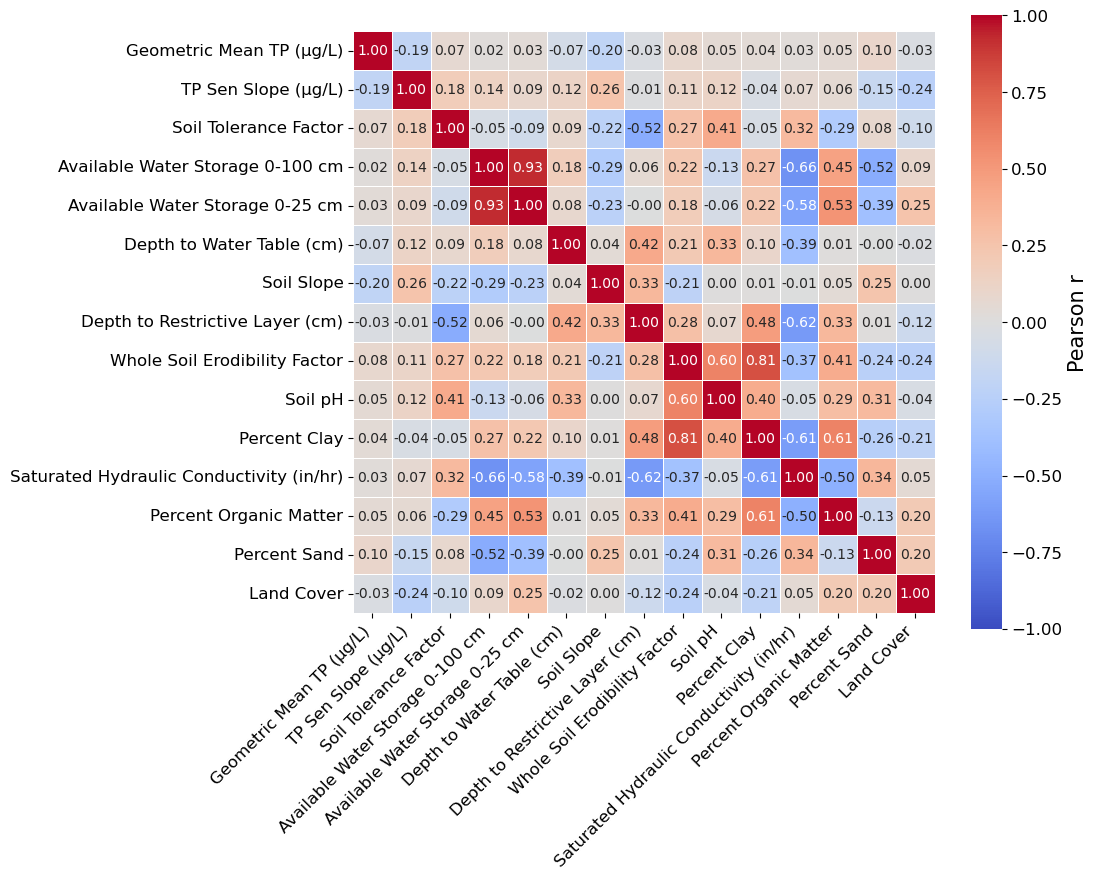

In [4]:
# --- Correlation analysis (optional; set RUN_CORRELATION = False to skip) ---
RUN_CORRELATION = True
if RUN_CORRELATION:
    corr = X.corr(method="pearson")
    labels = [VARIABLE_LABELS.get(c, c) for c in corr.columns]
    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
                square=True, linewidths=.5, cbar_kws={"label": "Pearson r"},
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    fig.tight_layout()
    fig.savefig(FIG / "correlation-heatmap.png", dpi=200)
    corr.to_csv(OUT / "correlation-matrix.csv")
    plt.show()

In [5]:
# --- PCA ---
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA().fit(X_std)
scores = pca.transform(X_std)

# Loadings = correlation of each variable with each component
loadings = pd.DataFrame(pca.components_.T * np.sqrt(pca.explained_variance_),
                        index=FEATURES,
                        columns=[f"PC{i+1}" for i in range(pca.n_components_)])

variance = pd.DataFrame({
    "PC": loadings.columns,
    "Variance %": (pca.explained_variance_ratio_ * 100).round(2),
    "Cumulative %": (np.cumsum(pca.explained_variance_ratio_) * 100).round(2),
    "Eigenvalue": pca.explained_variance_.round(3),
})
n90 = int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= .90) + 1)
print(f"PCs needed for 90% cumulative variance: {n90}\n")
print(variance.to_string(index=False))

# Top variables driving each retained component (justifies the PC names)
print("\nDominant loadings per retained component:")
for i in range(N_PCS_CLUSTER):
    pc = f"PC{i+1}"
    top = loadings[pc].sort_values(key=abs, ascending=False).head(4)
    drivers = ", ".join(f"{VARIABLE_LABELS.get(v, v)} ({loadings.loc[v, pc]:+.2f})"
                        for v in top.index)
    print(f"  {pc} — {PC_NAMES[pc]}: {drivers}")
loadings.iloc[:, :N_PCS_CLUSTER].round(3)

PCs needed for 90% cumulative variance: 8

  PC  Variance %  Cumulative %  Eigenvalue
 PC1       26.96         26.96       4.122
 PC2       15.45         42.41       2.361
 PC3       13.65         56.06       2.087
 PC4       10.15         66.20       1.551
 PC5        8.83         75.04       1.351
 PC6        7.38         82.41       1.128
 PC7        5.75         88.16       0.878
 PC8        3.24         91.40       0.495
 PC9        3.14         94.54       0.480
PC10        1.99         96.53       0.304
PC11        1.26         97.79       0.193
PC12        0.94         98.73       0.144
PC13        0.72         99.45       0.110
PC14        0.33         99.78       0.050
PC15        0.22        100.00       0.034

Dominant loadings per retained component:
  PC1 — Erodibility: Saturated Hydraulic Conductivity (in/hr) (+0.88), Percent Clay (-0.79), Available Water Storage 0-100 cm (-0.74), Percent Organic Matter (-0.73)
  PC2 — Drainage: Soil pH (+0.79), Whole Soil Erodibility Fa

,PC1,PC2,PC3,PC4,PC5
GMeanTP,-0.018,0.036,0.217,-0.484,-0.328
sen_slope,-0.089,0.156,0.114,0.703,0.387
TFACTOR,0.193,0.385,0.766,0.103,0.219
AWS100,-0.742,-0.529,0.275,0.110,0.174
AWS25,-0.691,-0.544,0.254,-0.058,0.301
DEP2WATTBL,-0.344,0.310,-0.126,0.181,0.351
SLOPE_1,0.107,0.237,-0.672,0.236,0.296
CM2RESLYR,-0.531,0.265,-0.710,0.024,-0.133
KFACTWS,-0.663,0.555,0.339,-0.027,-0.174
PHWATER,-0.255,0.786,0.265,-0.223,0.316


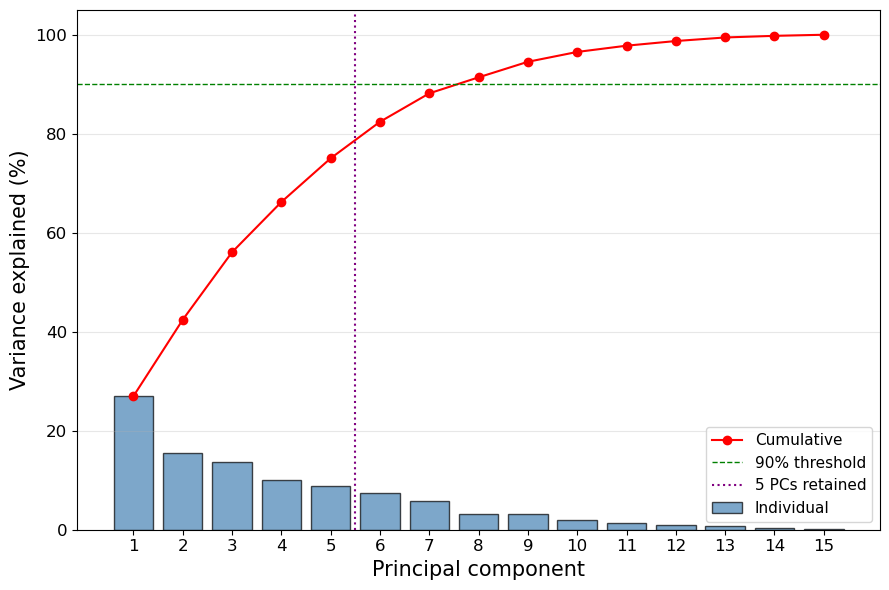

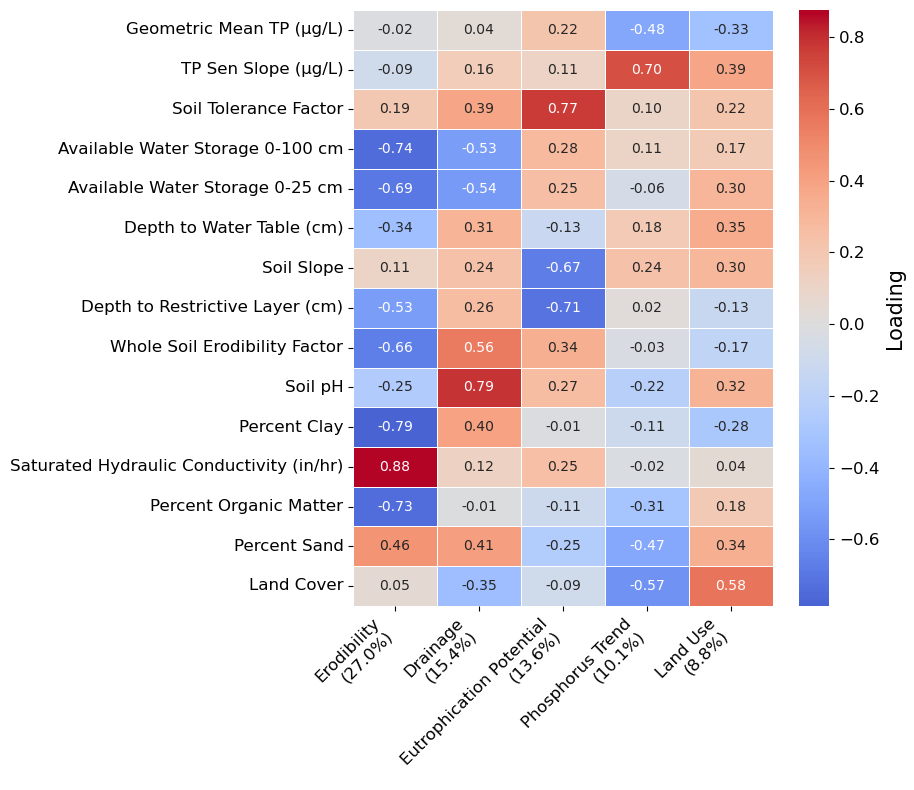

In [6]:
# --- PCA visualization: scree plot and loadings heatmap (saved separately) ---
pcs = np.arange(1, pca.n_components_ + 1)
vpct = pca.explained_variance_ratio_ * 100
cum = np.cumsum(vpct)

# Scree plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(pcs, vpct, color="steelblue", edgecolor="black", alpha=.7, label="Individual")
ax.plot(pcs, cum, "ro-", label="Cumulative")
ax.axhline(90, color="green", ls="--", lw=1, label="90% threshold")
ax.axvline(N_PCS_CLUSTER + .5, color="purple", ls=":", lw=1.5,
           label=f"{N_PCS_CLUSTER} PCs retained")
ax.set(xlabel="Principal component", ylabel="Variance explained (%)")
ax.set_xticks(pcs)
ax.legend()
ax.grid(axis="y", alpha=.3)
fig.tight_layout()
fig.savefig(FIG / "scree.png", dpi=200)
plt.show()

# Loadings heatmap (component names only, no "PCx")
disp = loadings.iloc[:, :N_PCS_CLUSTER].copy()
disp.index = [VARIABLE_LABELS.get(f, f) for f in disp.index]
disp.columns = [f"{PC_NAMES.get(c, c)}\n({v:.1f}%)"
                for c, v in zip(disp.columns, vpct)]
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(disp, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=.5,
            cbar_kws={"label": "Loading"}, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG / "loadings-heatmap.png", dpi=200)
plt.show()

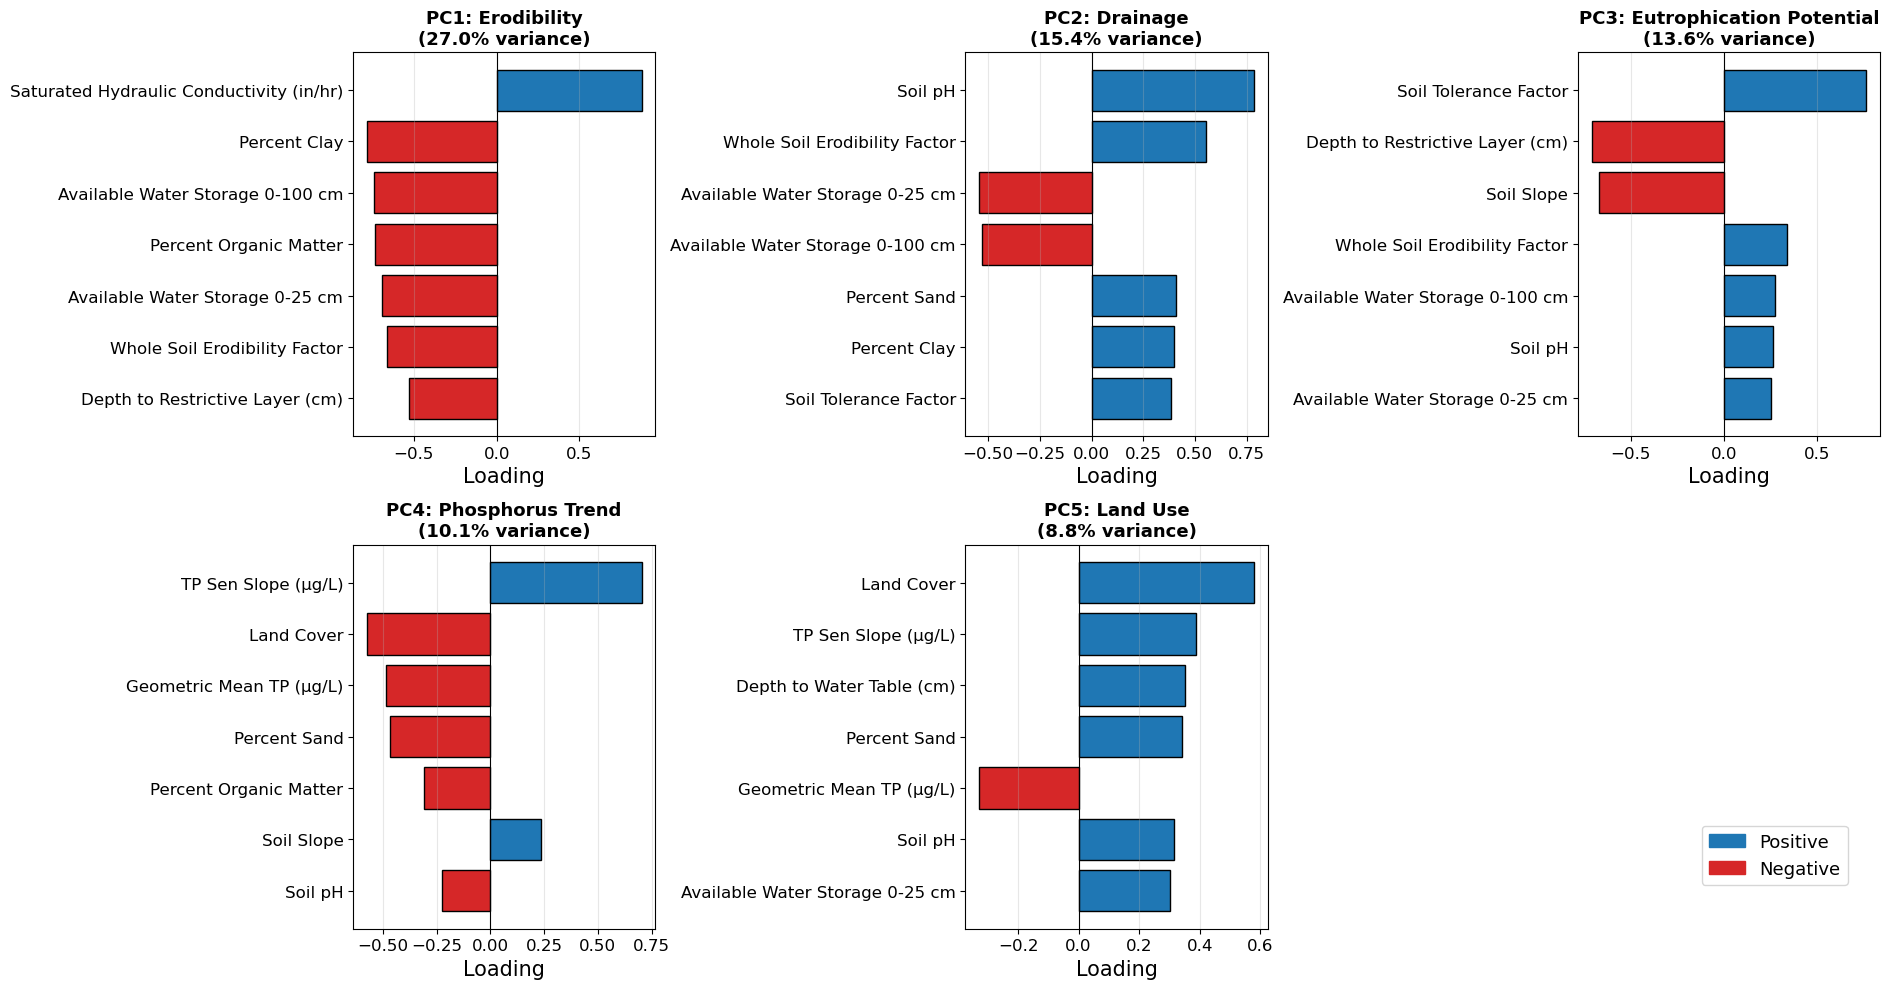

In [7]:
# --- Loadings facets: the 7 strongest |loadings| per retained PC ---
from matplotlib.patches import Patch

top_k = 7
pos_c, neg_c = "#1f77b4", "#d62728"
nrow, ncol = 2, 3
fig, axes = plt.subplots(nrow, ncol, figsize=(19, 10))
axes = axes.ravel()
for i in range(N_PCS_CLUSTER):
    ax = axes[i]
    pc = f"PC{i+1}"
    s = loadings[pc]
    top = s.reindex(s.abs().sort_values(ascending=False).index).head(top_k)
    top = top.iloc[::-1]               # largest |loading| ends up at the top of barh
    colors = [pos_c if v >= 0 else neg_c for v in top.values]
    ax.barh(range(len(top)), top.values, color=colors, edgecolor="black")
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([VARIABLE_LABELS.get(v, v) for v in top.index])
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"{pc}: {PC_NAMES[pc]}\n"
                 f"({pca.explained_variance_ratio_[i] * 100:.1f}% variance)",
                 fontweight="bold")
    ax.set_xlabel("Loading")
    ax.grid(axis="x", alpha=.3)
for j in range(N_PCS_CLUSTER, nrow * ncol):
    fig.delaxes(axes[j])
fig.legend(handles=[Patch(color=pos_c, label="Positive"),
                    Patch(color=neg_c, label="Negative")],
           loc="lower right", bbox_to_anchor=(0.98, 0.1), fontsize=13)
fig.tight_layout()
fig.savefig(FIG / "loadings-facets.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
# --- Clustering helpers (shared by both methods) ---
Z = scores[:, :N_PCS_CLUSTER]        # cluster on the first 5 PCs
K_RANGE = range(2, 11)

def cluster_labels(data, k, method):
    """k-means or Ward labels, relabeled so cluster 0 is the largest."""
    if method == "kmeans":
        lab = KMeans(k, random_state=RANDOM_STATE, n_init=10).fit_predict(data)
    else:
        lab = AgglomerativeClustering(k, linkage="ward").fit_predict(data)
    order = pd.Series(lab).value_counts().index.tolist()   # descending size
    remap = {old: i for i, old in enumerate(order)}
    return np.array([remap[v] for v in lab])

def centroids_of(data, labels):
    return np.vstack([data[labels == c].mean(0) for c in range(labels.max() + 1)])

def diagnostics(data, method):
    labs = {k: cluster_labels(data, k, method) for k in K_RANGE}
    tbl = pd.DataFrame({k: {"Silhouette": silhouette_score(data, l),
                            "Davies-Bouldin": davies_bouldin_score(data, l),
                            "Calinski-Harabasz": calinski_harabasz_score(data, l)}
                        for k, l in labs.items()}).T
    return tbl, labs

         Ward                                     k-means                                  agreement
   Silhouette Davies-Bouldin Calinski-Harabasz Silhouette Davies-Bouldin Calinski-Harabasz Adj. Rand
2       0.278          1.511            17.618      0.299          1.408            20.363     0.477
3       0.289          1.028            17.313      0.312          0.960            19.563     0.542
4       0.327          0.942            18.804      0.351          0.856            21.243     0.717
5       0.321          0.946            21.119      0.328          0.969            22.427     0.857
6       0.334          0.819            21.274      0.344          0.924            23.805     0.832
7       0.334          0.865            21.979      0.341          0.899            24.054     0.918
8       0.340          0.860            23.370      0.334          0.914            23.459     0.708
9       0.354          0.812            23.565      0.319          0.881            22.853 

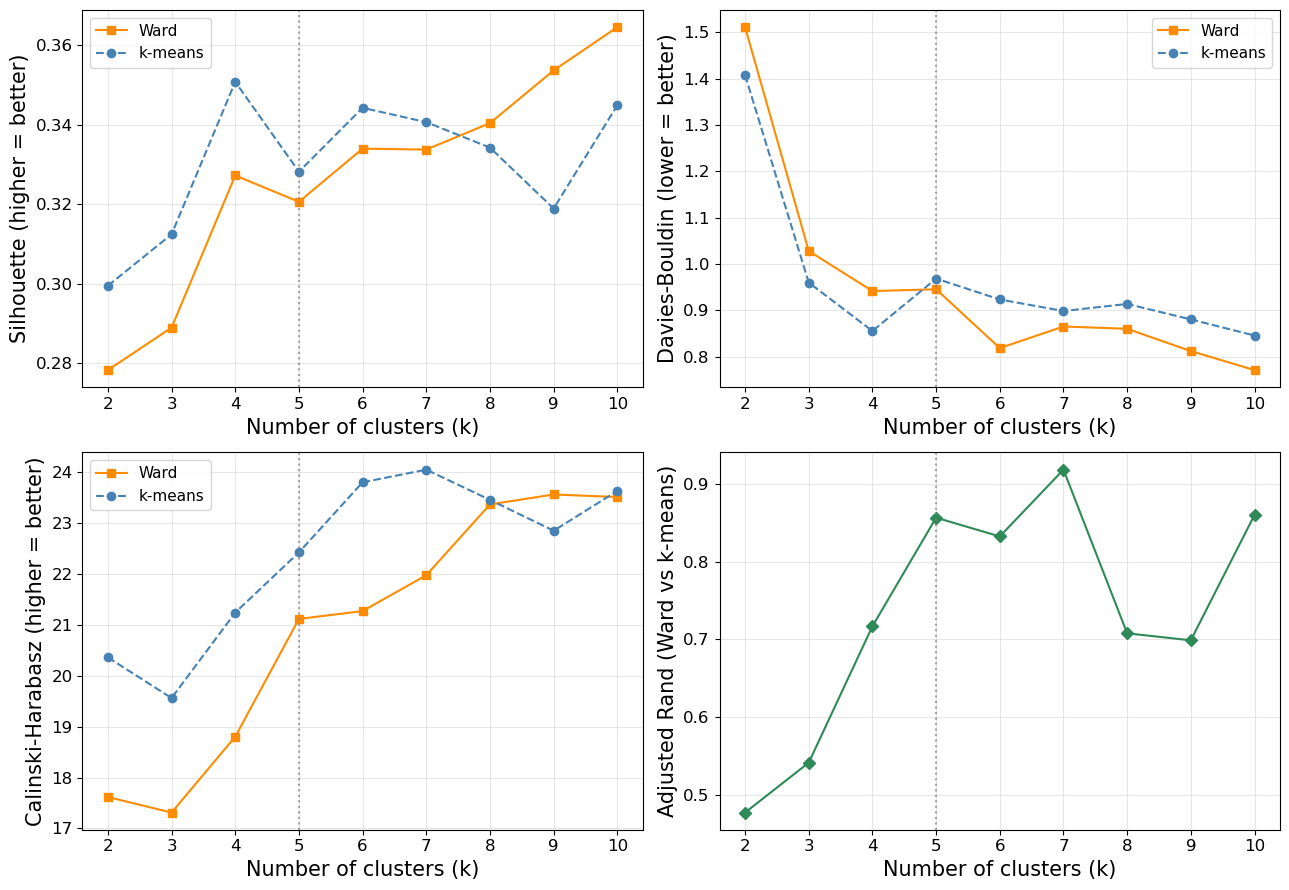

In [9]:
# --- Choosing k: Ward vs k-means across candidate cluster counts ---
diag_wd, labs_wd = diagnostics(Z, "ward")
diag_km, labs_km = diagnostics(Z, "kmeans")

# Adjusted Rand index between the two methods at each k (agreement / robustness)
ari = pd.Series({k: adjusted_rand_score(labs_wd[k], labs_km[k]) for k in K_RANGE})

compare = pd.concat({"Ward": diag_wd, "k-means": diag_km}, axis=1)
compare[("agreement", "Adj. Rand")] = ari
print(compare.round(3).to_string())
print(f"\nChosen K = {K}, method = {CLUSTER_METHOD}")

# 2 x 2 layout (paper-friendly): three internal metrics + method agreement
panels = [("Silhouette", "higher"), ("Davies-Bouldin", "lower"),
          ("Calinski-Harabasz", "higher")]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()
for ax, (name, better) in zip(axes, panels):
    ax.plot(diag_wd.index, diag_wd[name], "s-", color="darkorange", label="Ward")
    ax.plot(diag_km.index, diag_km[name], "o--", color="steelblue", label="k-means")
    ax.axvline(K, color="grey", ls=":", alpha=.7)
    ax.set(xlabel="Number of clusters (k)", ylabel=f"{name} ({better} = better)")
    ax.set_xticks(list(K_RANGE))
    ax.grid(alpha=.3)
    ax.legend()
axes[3].plot(ari.index, ari.values, "D-", color="seagreen")
axes[3].axvline(K, color="grey", ls=":", alpha=.7)
axes[3].set(xlabel="Number of clusters (k)",
            ylabel="Adjusted Rand (Ward vs k-means)")
axes[3].set_xticks(list(K_RANGE))
axes[3].grid(alpha=.3)
fig.tight_layout()
fig.savefig(FIG / "cluster-metrics.png", dpi=200)
plt.show()

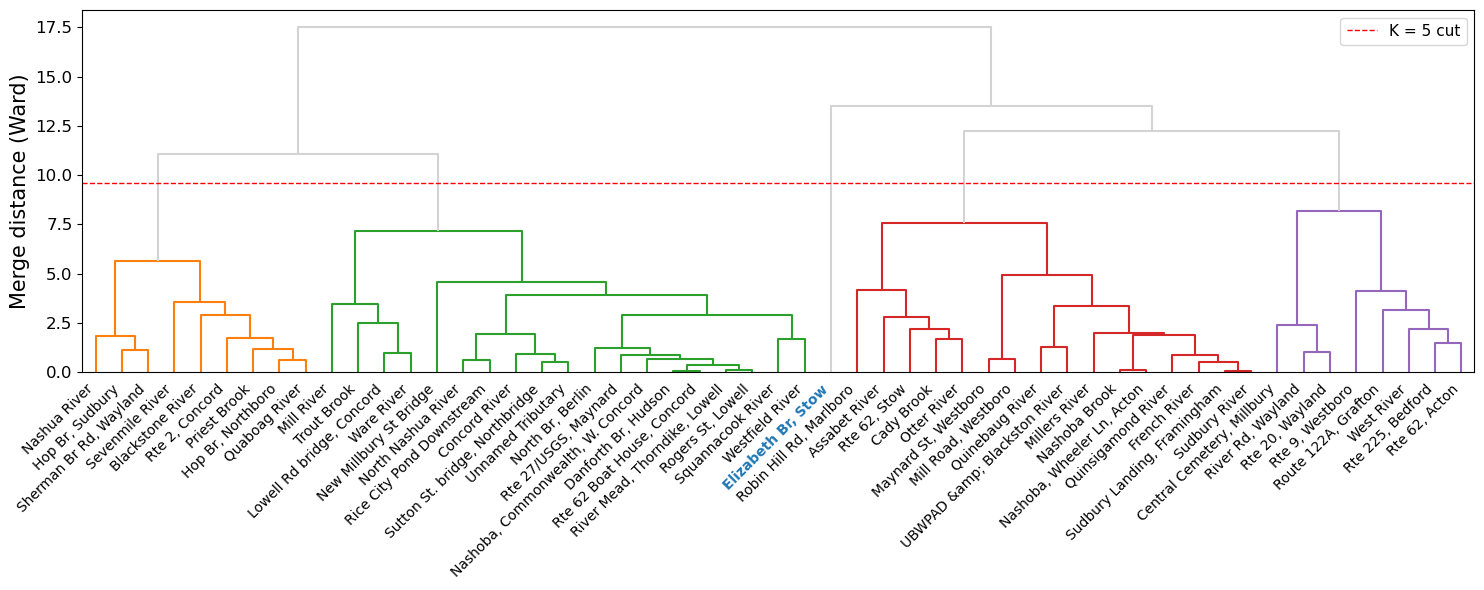

In [10]:
# --- Ward dendrogram (hierarchy behind the chosen cut) ---
link = linkage(Z, method="ward")
d = np.sort(link[:, 2])
thr = 0.5 * (d[-K] + d[-(K - 1)])     # cut that yields K clusters

# Singleton sites (size-1 Ward clusters) get a blue leaf label instead of grey
_wl = cluster_labels(Z, K, "ward")
_sizes = pd.Series(_wl).value_counts()
singleton_sites = set(train["MonitoringLocationName"].values[
    np.isin(_wl, _sizes.index[_sizes == 1])])

fig, ax = plt.subplots(figsize=(15, 6))
dendrogram(link, labels=train["MonitoringLocationName"].values,
           color_threshold=thr, above_threshold_color="lightgrey", ax=ax)
ax.axhline(thr, color="red", ls="--", lw=1, label=f"K = {K} cut")
ax.set(ylabel="Merge distance (Ward)")
ax.tick_params(axis="x", labelsize=10)
for lbl in ax.get_xticklabels():
    lbl.set_rotation(45)
    lbl.set_ha("right")
    if lbl.get_text() in singleton_sites:
        lbl.set_color(PALETTE[0])          # blue, to match the other plots
        lbl.set_fontweight("bold")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "ward-dendrogram.png", dpi=200)
plt.show()

Method: ward   K = 5   silhouette = 0.321   agreement with kmeans (ARI) = 0.857

Cluster sizes:
Cluster
0    19
1    16
2     9
3     8
4     1


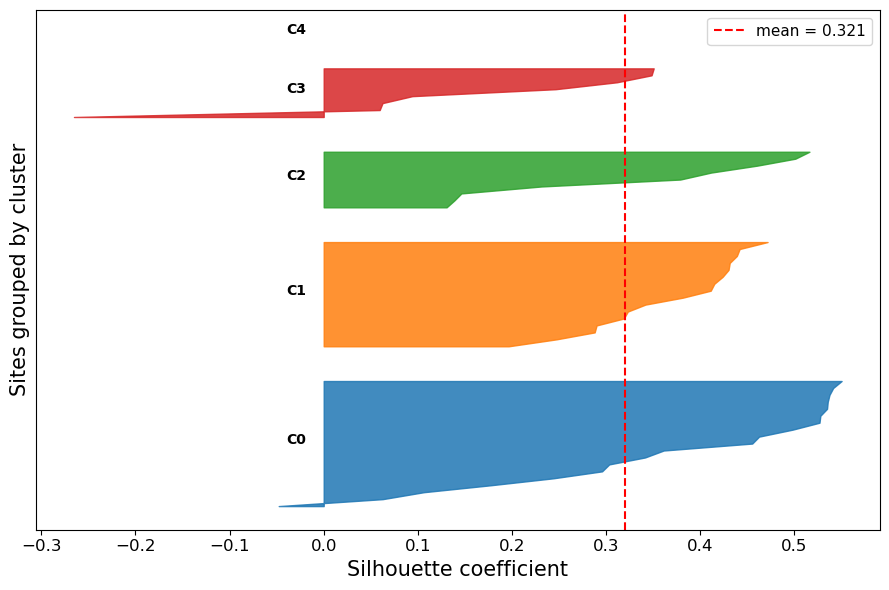

In [11]:
# --- Fit the chosen clustering and inspect the per-site silhouette plot ---
labels = cluster_labels(Z, K, CLUSTER_METHOD)
train["Cluster"] = labels
centers = centroids_of(Z, labels)

other = "kmeans" if CLUSTER_METHOD == "ward" else "ward"
agree = adjusted_rand_score(labels, cluster_labels(Z, K, other))
sil_avg = silhouette_score(Z, labels)
print(f"Method: {CLUSTER_METHOD}   K = {K}   silhouette = {sil_avg:.3f}   "
      f"agreement with {other} (ARI) = {agree:.3f}")
print("\nCluster sizes:")
print(train["Cluster"].value_counts().sort_index().to_string())

sil_vals = silhouette_samples(Z, labels)
fig, ax = plt.subplots(figsize=(9, 6))
y = 0
for c in range(K):
    vals = np.sort(sil_vals[labels == c])
    ax.fill_betweenx(np.arange(y, y + len(vals)), 0, vals, color=PALETTE[c], alpha=.85)
    ax.text(-0.04, y + len(vals) / 2, f"C{c}", va="center", fontweight="bold")
    y += len(vals) + 4
ax.axvline(sil_avg, color="red", ls="--", label=f"mean = {sil_avg:.3f}")
ax.set(xlabel="Silhouette coefficient", ylabel="Sites grouped by cluster")
ax.set_yticks([])
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "silhouette-knife.png", dpi=200)
plt.show()

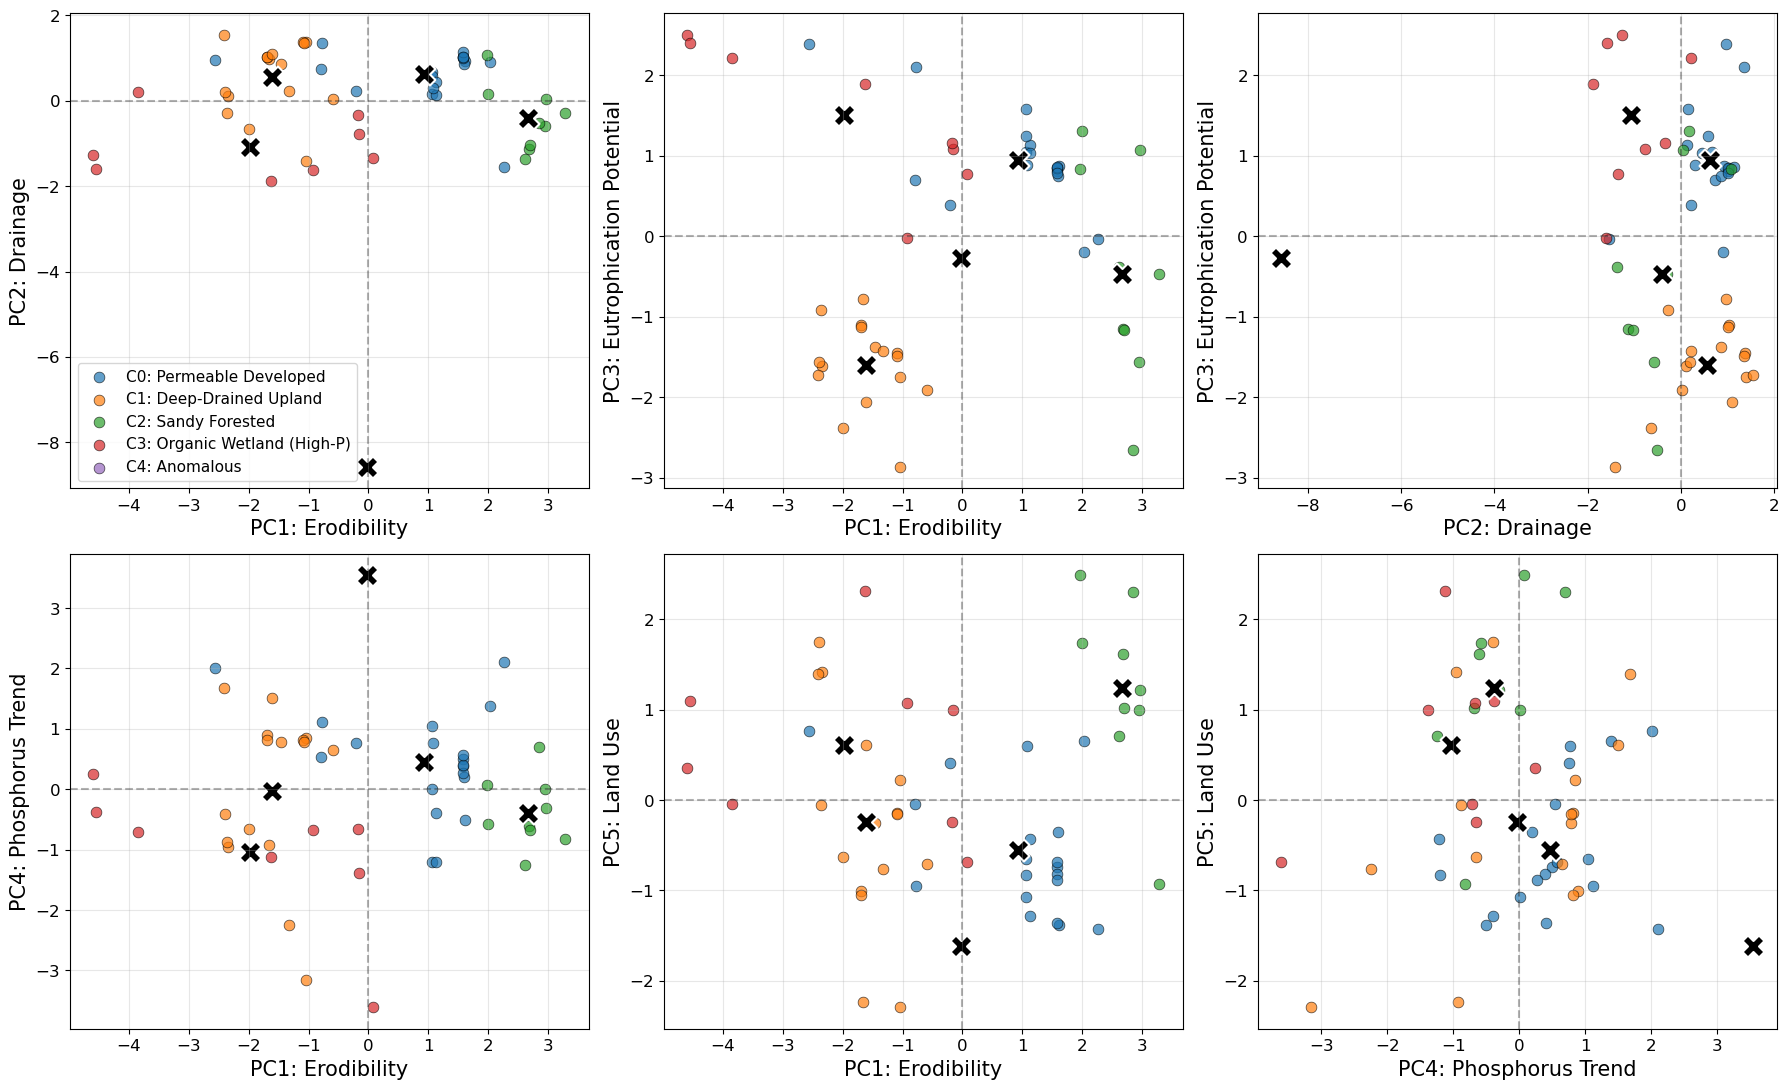

In [12]:
# --- Cluster visualization in PC space (six PC pairs spanning PC1-PC5) ---
pairs = [(0, 1), (0, 2), (1, 2), (0, 3), (0, 4), (3, 4)]
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()
for ax, (a, b) in zip(axes, pairs):
    for c in range(K):
        m = labels == c
        ax.scatter(Z[m, a], Z[m, b], c=[PALETTE[c]], s=60, alpha=.7,
                   edgecolors="black", linewidth=.5, label=f"C{c}: {CLUSTER_NAMES[c]}")
    ax.scatter(centers[:, a], centers[:, b], c="black", marker="X", s=250,
               edgecolors="white", linewidth=1.5)
    ax.axhline(0, color="k", ls="--", alpha=.3)
    ax.axvline(0, color="k", ls="--", alpha=.3)
    ax.set(xlabel=f"PC{a+1}: {PC_NAMES[f'PC{a+1}']}",
           ylabel=f"PC{b+1}: {PC_NAMES[f'PC{b+1}']}")
    ax.grid(alpha=.3)
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG / "score-plots.png", dpi=200)
plt.show()

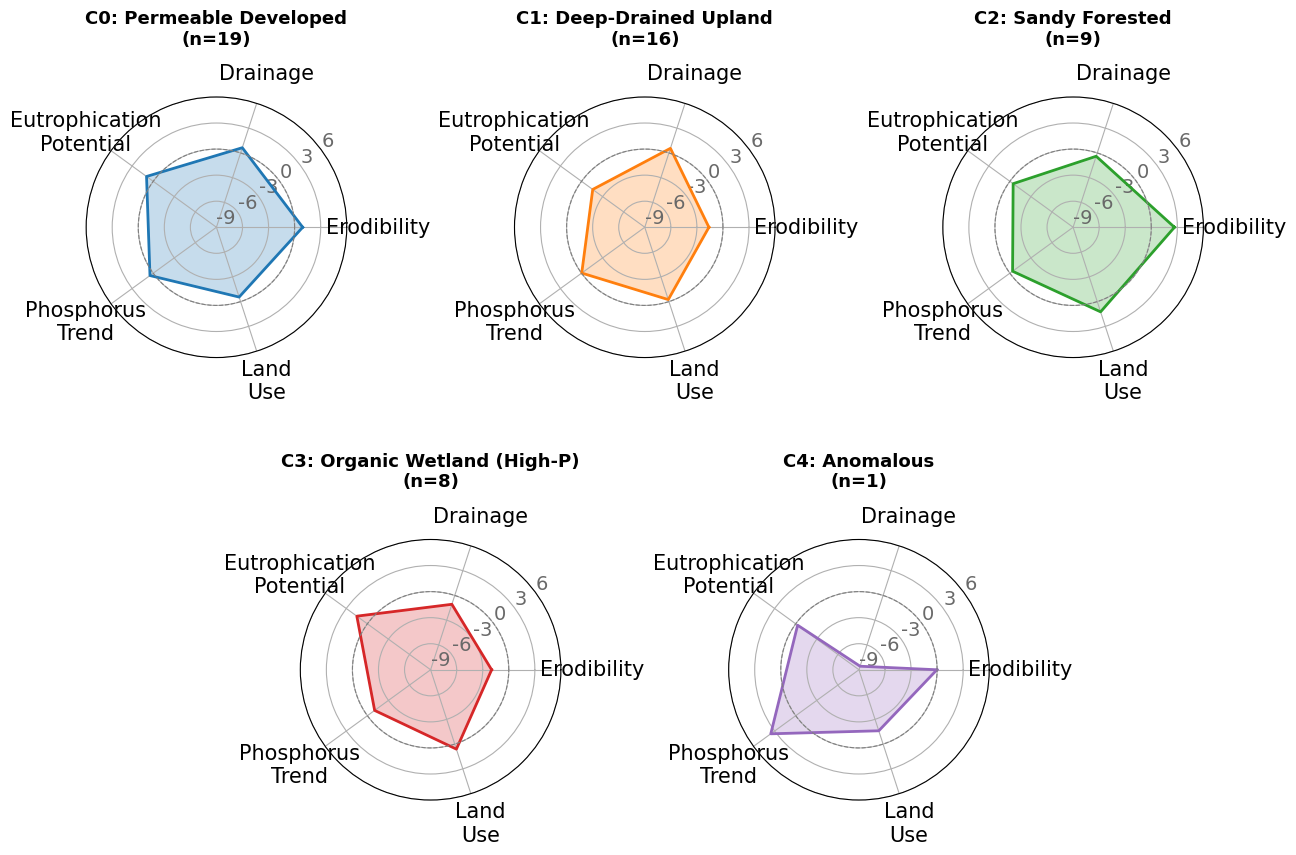

Mean PC scores per cluster:
          PC1   PC2   PC3   PC4   PC5
Cluster                              
0        0.93  0.63  0.95  0.46 -0.55
1       -1.61  0.55 -1.59 -0.03 -0.24
2        2.67 -0.40 -0.47 -0.39  1.24
3       -1.98 -1.07  1.50 -1.04  0.61
4       -0.02 -8.57 -0.27  3.54 -1.61


In [13]:
# --- Radar plots: cluster profiles from mean PC scores (one per cluster) ---
pc_cols = [f"PC{i+1}" for i in range(N_PCS_CLUSTER)]
pc_mean = pd.DataFrame(Z, columns=pc_cols).assign(Cluster=labels).groupby("Cluster").mean()

angles = np.linspace(0, 2 * np.pi, N_PCS_CLUSTER, endpoint=False)
loop = np.concatenate([angles, angles[:1]])
ring = np.linspace(0, 2 * np.pi, 100)
RMIN, RMAX = -9, 6                      # shared radial scale for every cluster
rticks = np.arange(RMIN, RMAX + 1, 3)  # -9, -6, -3, 0, 3, 6

def wrap2(name):
    """Break a component name onto two lines so labels clear the axes."""
    words = name.split()
    if len(words) == 1:
        return name
    mid = len(words) // 2
    return " ".join(words[:mid]) + "\n" + " ".join(words[mid:])

axis_labels = [wrap2(PC_NAMES[f"PC{i+1}"]) for i in range(N_PCS_CLUSTER)]

# 3 radars on top, 2 centered below: 6-column grid, bottom pair spans cols 1-3 & 3-5
fig = plt.figure(figsize=(13, 9))
gs = fig.add_gridspec(2, 6)
cells = [gs[0, 0:2], gs[0, 2:4], gs[0, 4:6], gs[1, 1:3], gs[1, 3:5]]
radar_axes = [fig.add_subplot(cells[c], projection="polar") for c in range(K)]

for c in range(K):
    ax = radar_axes[c]
    vals = pc_mean.loc[c].tolist() + pc_mean.loc[c].tolist()[:1]
    ax.plot(loop, vals, color=PALETTE[c], lw=2)
    ax.fill(loop, vals, color=PALETTE[c], alpha=.25)
    ax.plot(ring, [0] * 100, color="grey", lw=.8, ls="--")
    ax.set_xticks(angles)
    ax.set_xticklabels(axis_labels, fontsize=15)
    ax.tick_params(axis="x", pad=12)
    ax.set_ylim(RMIN, RMAX)
    ax.set_yticks(rticks)
    ax.set_yticklabels([f"{t:g}" for t in rticks], fontsize=14, color="dimgrey")
    ax.set_rlabel_position(36)
    ax.set_title(f"C{c}: {CLUSTER_NAMES[c]}\n(n={int((labels == c).sum())})",
                 fontsize=13, fontweight="bold", pad=14)
fig.tight_layout()
fig.savefig(FIG / "typology-radar.png", dpi=200, bbox_inches="tight")
plt.show()

print("Mean PC scores per cluster:")
print(pc_mean.round(2).to_string())

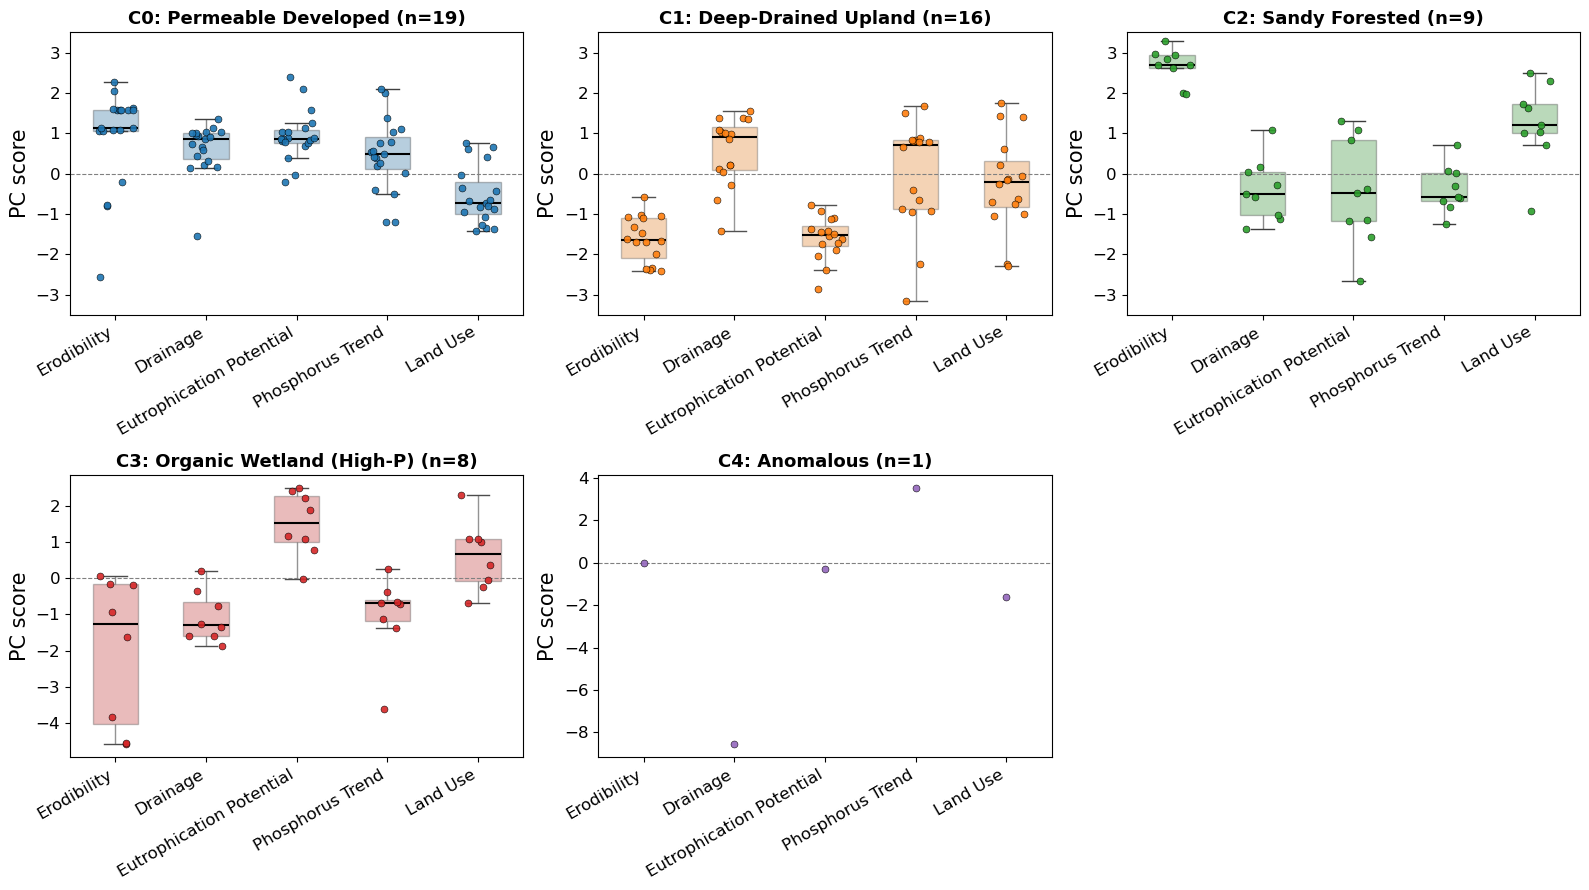

In [14]:
# --- PC-score distribution per cluster: box summary + individual sites ---
pc_long = (pd.DataFrame(Z, columns=pc_cols)
           .assign(Cluster=labels)
           .melt(id_vars="Cluster", var_name="PC", value_name="Score"))
tick_names = [PC_NAMES[p] for p in pc_cols]

np.random.seed(RANDOM_STATE)   # fix strip-plot jitter so the figure is reproducible
nrow, ncol = 2, 3          # top row shares a -3.5..3.5 scale; bottom row auto-scaled
fig, axes = plt.subplots(nrow, ncol, figsize=(16, 9))
axes = axes.ravel()
for c in range(K):
    ax = axes[c]
    sub = pc_long[pc_long["Cluster"] == c]
    n = int((labels == c).sum())
    if n > 1:                          # skip the box for a single-site cluster
        sns.boxplot(data=sub, x="PC", y="Score", order=pc_cols, ax=ax,
                    color=PALETTE[c], width=.5, fliersize=0, showcaps=True,
                    boxprops=dict(alpha=.35), whiskerprops=dict(alpha=.6),
                    medianprops=dict(color="black", lw=1.5))
    sns.stripplot(data=sub, x="PC", y="Score", order=pc_cols, ax=ax,
                  color=PALETTE[c], size=5, jitter=.2,
                  edgecolor="black", linewidth=.4, alpha=.9)
    ax.axhline(0, color="grey", lw=.8, ls="--")
    if c < ncol:                       # top row: common y-limits
        ax.set_ylim(-3.5, 3.5)
    ax.set_title(f"C{c}: {CLUSTER_NAMES[c]} (n={n})", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("PC score")
    ax.set_xticks(range(len(pc_cols)))
    ax.set_xticklabels(tick_names, rotation=30, ha="right", fontsize=12)
for j in range(K, nrow * ncol):
    fig.delaxes(axes[j])
fig.tight_layout()
fig.savefig(FIG / "pc-score-distribution.png", dpi=200)
plt.show()

In [15]:
# --- Cluster characterization ---
profile = train.groupby("Cluster")[FEATURES].mean().T
profile.index = [VARIABLE_LABELS.get(f, f) for f in profile.index]
print("Mean feature profile per cluster:")
print(profile.round(2).to_string())

print("\nLand cover by cluster:")
print(pd.crosstab(train["Cluster"], train["Land_Cover"]).to_string())

Mean feature profile per cluster:
Cluster                                       0      1      2      3      4
Geometric Mean TP (µg/L)                  43.27  43.36  43.82  52.26  30.80
TP Sen Slope (µg/L)                       -0.15  -0.26  -0.14  -0.34   0.00
Soil Tolerance Factor                      4.11   2.81   3.67   3.75   2.00
Available Water Storage 0-100 cm           8.28  11.46   7.25  18.95  30.23
Available Water Storage 0-25 cm            2.73   3.66   2.70   6.41   7.81
Depth to Water Table (cm)                 11.26  45.81  24.11  10.25   0.00
Soil Slope                                 5.79  10.31   9.67   1.38   0.00
Depth to Restrictive Layer (cm)            0.00  69.31   0.00   0.00   0.00
Whole Soil Erodibility Factor              0.27   0.28   0.12   0.28   0.00
Soil pH                                    5.18   5.12   4.83   5.52   0.00
Percent Clay                               5.51   7.21   2.00   6.31   0.00
Saturated Hydraulic Conductivity (in/hr)  80.53  10.00

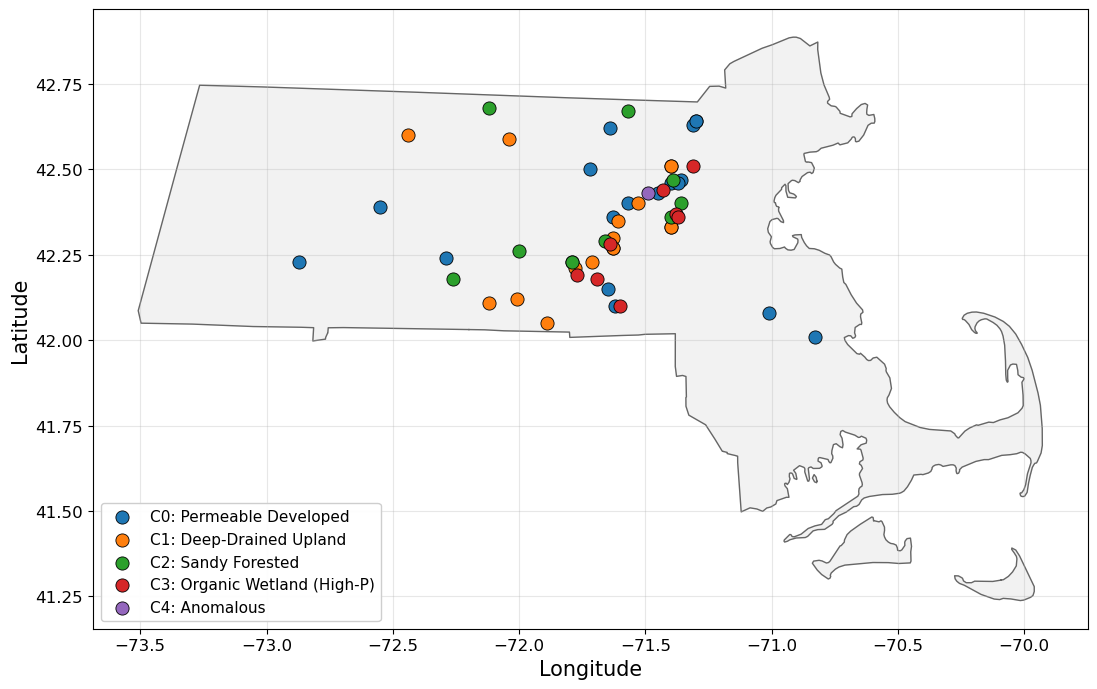

In [16]:
# --- Site map: training stations over the Massachusetts outline ---
import json

ma = json.load(open(ROOT / "data" / "geo" / "massachusetts.geojson"))

def iter_rings(geom):
    if geom["type"] == "Polygon":
        yield from geom["coordinates"]
    else:                                  # MultiPolygon (mainland + islands)
        for poly in geom["coordinates"]:
            yield from poly

fig, ax = plt.subplots(figsize=(12, 7))
for ring in iter_rings(ma["geometry"]):
    xs, ys = zip(*ring)
    ax.fill(xs, ys, color="0.95", zorder=0)
    ax.plot(xs, ys, color="0.4", lw=1, zorder=1)

for c in range(K):
    m = train["Cluster"] == c
    ax.scatter(train.loc[m, "Longitude"], train.loc[m, "Latitude"],
               c=[PALETTE[c]], s=90, edgecolors="black", linewidth=.6,
               label=f"C{c}: {CLUSTER_NAMES[c]}", zorder=3)

ax.set_aspect(1 / np.cos(np.deg2rad(train["Latitude"].mean())))  # geographic aspect
ax.set(xlabel="Longitude", ylabel="Latitude")
ax.legend(loc="lower left", framealpha=.95)
ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig(FIG / "typology-site-map.png", dpi=200, bbox_inches="tight")
plt.show()

## Cluster interpretation (Ward, K = 5)

The five Ward clusters separate the training sites into four physically coherent
stream types plus a lone anomalous record. Signals below reference the mean
principal-component scores and the raw soil / water-quality features.

| Cluster | n | Type | Distinguishing signals | Dominant land cover |
|---|---|---|---|---|
| **0 — Permeable Developed** | 19 | Well-drained developed catchments, moderate eutrophication potential | High KSAT (~80 in/hr), low clay; +PC1 (Erodibility), +PC3 (Eutrophication Potential) | Developed, medium / low intensity |
| **1 — Deep-Drained Upland** | 16 | Low-conductivity soils, deep water table, low eutrophication potential | KSAT ~10, water table ~46 cm, steeper slopes; -PC1, -PC3 | Developed medium / deciduous forest |
| **2 — Sandy Forested** | 9 | Very permeable sandy soils under forest and pasture | Highest KSAT (~98), lowest clay (~2%); strongly +PC1, +PC5 (Land Use) | Mixed / evergreen forest, pasture |
| **3 — Organic Wetland (High-P)** | 8 | Poorly-drained organic wetland soils, highest TP and eutrophication potential | Highest organic matter (~10%) and TP (~52 ug/L), flat, near-zero slope; -PC2 (Drainage), +PC3 | Woody / emergent wetlands |
| **4 — Anomalous** | 1 | Single anomalous site, **Elizabeth Br, Stow**, with all-zero soil attributes | PC2 ~ -8.6 (all soil fields report 0) | isolated by both Ward and k-means; likely a data-entry gap |

In short, PC1 (permeability / erodibility) is the primary axis separating the
sandy forested (C2) and permeable developed (C0) sites from the low-conductivity
group (C1), while PC3 (eutrophication potential) and PC2 (drainage) isolate the
high-phosphorus wetland group (C3). Cluster 4 is a data artifact rather than a
genuine stream type and should be reviewed in `data/tidy` before publication.

In [17]:
# --- Save the labeled typology and the fitted model bundle ---
# Classification for new sites uses nearest centroid, so the bundle works for
# either method (Ward has no native predict()).
train[ID_COLS + FEATURES + ["Cluster"]].assign(
    Type=train["Cluster"].map(CLUSTER_NAMES)).to_csv(
    OUT / "typology-training-labeled.csv", index=False)

joblib.dump({
    "scaler": scaler, "pca": pca,
    "cluster_method": CLUSTER_METHOD, "k": K, "centroids": centers,
    "features": FEATURES, "id_cols": ID_COLS, "lulc_mapping": lulc_mapping,
    "pc_names": PC_NAMES, "cluster_names": CLUSTER_NAMES,
    "variable_labels": VARIABLE_LABELS,
    "n_pcs_cluster": N_PCS_CLUSTER, "test_sites": TEST_SITES,
    "train_scores": Z, "train_labels": labels,
}, OUT / "typology-model.joblib")
print(f"Saved typology ({CLUSTER_METHOD}, K={K}) and model bundle to", OUT)

Saved typology (ward, K=5) and model bundle to /home/jbo/Projects/stream-station-typology/results
